# 📊 Adım 7 — İstatistiksel Analiz

Modellerimiz arasında istatistiksel anlamlı fark var mı?

**Neden gerekli?**  
Tek bir test setinde ET'nin RF'den daha iyi görünmesi şans eseri olabilir.  
20 split üzerinden **istatistiksel testler** bunu netleştirir.

> **Finansal analoji:** Bir fon yöneticisi 3 yıl boyunca piyasayı yendi.  
> Ama bu alpha mı, yoksa şans mı? Sharpe ratio ve t-testi bunu ayırt eder.  
> Biz de aynısını yapıyoruz: Wilcoxon + Friedman = ML'nin Sharpe ratio testi.

**Testler:**
- **Friedman Testi:** 3 model arasında genel fark var mı?  
- **Wilcoxon Signed-Rank:** İkili karşılaştırmalar (RF vs ET, RF vs GB, ET vs GB)  
- **Bonferroni Düzeltmesi:** 3 karşılaştırma yaptığımız için p-değerini sıkılaştırıyoruz  

---

In [1]:
# ── Kütüphane İmportları ────────────────────────────────────────────────────
# Veri işleme ve matematiksel hesaplamalar için temel kütüphaneler
import pandas as pd
import numpy as np
from scipy import stats          # Friedman ve Wilcoxon istatistiksel testleri için
import matplotlib.pyplot as plt  # Grafik çizimi
import seaborn as sns            # Gelişmiş görselleştirme
import warnings
warnings.filterwarnings('ignore')

# Ağaç tabanlı modeller (asıl modellerimiz — Optuna ile optimize edilecek)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

# Baseline karşılaştırma modelleri (sabit parametreler, Optuna yok)
from sklearn.linear_model import LogisticRegression  # Doğrusal baseline
from sklearn.svm import SVC                          # Kernel tabanlı baseline
from sklearn.neighbors import KNeighborsClassifier   # Mesafe tabanlı baseline

# Kalibrasyon, çapraz doğrulama ve metrik araçları
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score, roc_auc_score

# Ön işleme araçları
from sklearn.impute import SimpleImputer        # Eksik değer doldurma (medyan)
from sklearn.preprocessing import RobustScaler  # Ölçekleme (aykırı değere dayanıklı)
from sklearn.feature_selection import VarianceThreshold  # Sabit özellik eleme

# MRMR: Minimum Redundancy Maximum Relevance özellik seçimi
from mrmr import mrmr_classif

# Optuna: Bayesci hiperparametre optimizasyonu
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # Gereksiz log çıktısını kapat

np.random.seed(42)               # Tekrarlanabilirlik için sabit rastgelelik
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')
print('Kütüphaneler hazır ✓')


Kütüphaneler hazır ✓


In [2]:
# ── Veri Yükleme ─────────────────────────────────────────────────────────────
# İki ayrı CSV dosyasından normal ve papilödem hastalarını oku
normal = pd.read_csv('../data/normal_radiomics.csv')   # 48 hasta, 746 radiomik özellik
papil  = pd.read_csv('../data/papilodem_radiomics.csv') # 21 hasta, 746 radiomik özellik

# Sınıf etiketlerini ekle: Normal=0, Papilödem=1
normal['label'] = 0
papil['label']  = 1

# ÖNEMLİ: Her iki CSV'de de PatientIndex 1'den başlıyor.
# Normal: 1-48, Papilödem: 1-21 → aynı numaralar var!
# Birleştirince model aynı numaralı hastaları aynı kişi sanır.
# Fix: Papilödem hasta numaralarına 1000 ekle → 1001-1021 olur, çakışma kalmaz.
papil['PatientIndex'] = papil['PatientIndex'] + 1000

# İki veri kümesini tek DataFrame'de birleştir
df = pd.concat([normal, papil], ignore_index=True)

# Radiomik özellik sütunlarını belirle (Feature_ ile başlayanlar)
feature_cols = [c for c in df.columns if c.startswith('Feature_')]


# ── Hasta Bazında Veri Bölme Fonksiyonu ──────────────────────────────────────
def hasta_bazinda_bol(df, test_ratio=0.20, val_ratio=0.10, random_state=42):
    """
    Veriyi HASTA bazında train/val/test olarak böler.
    Kritik kural: Aynı hastanın tüm görüntüleri aynı grupta olmalı.
    Örneğin Hasta-5'in 14 görüntüsü ya tamamen train'de ya tamamen test'te.
    Aksi takdirde model o hastayı 'tanımış' olur → veri sızıntısı (data leakage).
    
    Parametreler:
      test_ratio  : Test için ayrılacak hasta oranı (default %20)
      val_ratio   : Validasyon için ayrılacak hasta oranı (default %10)
      random_state: Tekrarlanabilirlik için rastgelelik tohumu
    """
    rng = np.random.RandomState(random_state)
    
    # Her hastanın sınıf etiketini al (bir hastanın tek etiketi var)
    hasta_etiket = df.groupby('PatientIndex')['label'].first()
    
    train_idx, val_idx, test_idx = [], [], []
    
    # Her sınıf için ayrı ayrı böl → sınıf dengesi korunur (stratified)
    for sinif in [0, 1]:
        hastalar = hasta_etiket[hasta_etiket == sinif].index.tolist()
        rng.shuffle(hastalar)  # Karıştır
        n = len(hastalar)
        n_test = max(1, int(n * test_ratio))
        n_val  = max(1, int(n * val_ratio))
        test_idx  += hastalar[:n_test]
        val_idx   += hastalar[n_test:n_test + n_val]
        train_idx += hastalar[n_test + n_val:]
    
    return (df[df['PatientIndex'].isin(train_idx)].copy(),
            df[df['PatientIndex'].isin(val_idx)].copy(),
            df[df['PatientIndex'].isin(test_idx)].copy())


# ── Radiomik Ön İşleme Pipeline'ı ───────────────────────────────────────────
class RadyomikOnIsleme:
    """
    4 adımlı ön işleme pipeline'ı:
    1. Eksik değer doldurma  : Medyan ile (ortalamadan daha dayanıklı)
    2. Varyans filtresi      : Hiç değişmeyen özellikleri at (eşik: 0.01)
    3. Korelasyon filtresi   : Birbirine >%95 benzeyen özelliklerden birini at
    4. RobustScaler          : Özellikleri aynı ölçeğe getir (aykırı değere dayanıklı)
    
    ÖNEMLI: fit() SADECE train verisine çağrılır.
    transform() train, val ve test'e ayrı ayrı uygulanır.
    Test verisinin istatistikleri öğrenmeye dahil edilmez → veri sızıntısı önlenir.
    """
    def __init__(self, vt=0.01, ct=0.95):
        self.imputer  = SimpleImputer(strategy='median')
        self.var_sel  = VarianceThreshold(threshold=vt)  # Varyans eşiği
        self.scaler   = RobustScaler()
        self.feats_var = self.feats_corr = None          # Seçilen özellik isimleri
    
    def fit(self, X, fn):
        # Sonsuz değerleri NaN'a çevir, sonra medyanla doldur
        X = np.where(np.isinf(X), np.nan, X)
        X = self.imputer.fit_transform(X)
        
        # Varyans filtresi uygula
        self.var_sel.fit(X)
        m = self.var_sel.get_support()
        self.feats_var = [f for f, v in zip(fn, m) if v]
        X = X[:, m]
        
        # Yüksek korelasyonlu özellikleri at (r > 0.95)
        up = pd.DataFrame(X, columns=self.feats_var).corr().abs().where(
            np.triu(np.ones((len(self.feats_var),)*2), k=1).astype(bool))
        drop = [c for c in up.columns if any(up[c] > 0.95)]
        self.feats_corr = [f for f in self.feats_var if f not in drop]
        
        # RobustScaler: sadece kalan özellikler için fit et
        ki = [self.feats_var.index(f) for f in self.feats_corr]
        self.scaler.fit(X[:, ki])
        return self
    
    def transform(self, X, fn):
        # Öğrenilen parametrelerle dönüşümü uygula (fit YOK)
        X = np.where(np.isinf(X), np.nan, X)
        X = self.imputer.transform(X)
        X = pd.DataFrame(X, columns=fn)[self.feats_var].values
        X = pd.DataFrame(X, columns=self.feats_var)[self.feats_corr].values
        return self.scaler.transform(X)
    
    def fit_transform(self, X, fn):
        self.fit(X, fn)
        return self.transform(X, fn)


# ── Optuna Hiperparametre Optimizasyon Fonksiyonu ────────────────────────────
def optuna_en_iyi_params(X_tr, y_tr, groups, model_adi, n_trials=50):
    """
    Verilen model için Bayesci optimizasyon (TPE Sampler) ile en iyi
    hiperparametreleri bulur.
    
    Inner CV: StratifiedGroupKFold(3) — hasta gruplarına göre 3 katlı çapraz doğrulama.
    Her trial: farklı parametre kombinasyonu → CV skoru → Optuna'ya bildir.
    50 trial sonunda en yüksek Macro-F1 veren parametreler döner.
    
    Sadece RF, ET, GB için kullanılır. LR/SVM/KNN baseline olduğu için
    Optuna ile optimize edilmez, sabit parametreler kullanılır.
    """
    inner_cv = StratifiedGroupKFold(n_splits=5)
    
    def objective(trial):
        if model_adi == 'LR':
            from sklearn.linear_model import LogisticRegression
            model = LogisticRegression(
                C       = trial.suggest_float('C', 0.01, 10.0, log=True),
                max_iter= 1000,
                random_state=42)
        elif model_adi == 'SVM':
            from sklearn.svm import SVC
            model = SVC(
                C       = trial.suggest_float('C', 0.01, 10.0, log=True),
                gamma   = trial.suggest_categorical('gamma', ['scale', 'auto']),
                kernel  = 'rbf',
                probability=True,
                random_state=42)
        elif model_adi == 'KNN':
            from sklearn.neighbors import KNeighborsClassifier
            model = KNeighborsClassifier(
                n_neighbors = trial.suggest_int('n_neighbors', 3, 15),
                weights     = trial.suggest_categorical('weights', ['uniform', 'distance']),
                metric      = trial.suggest_categorical('metric', ['euclidean', 'manhattan']))
        elif model_adi in ['RF', 'ET']:
            Cls = RandomForestClassifier if model_adi == 'RF' else ExtraTreesClassifier
            model = Cls(
                n_estimators     = trial.suggest_int('n_estimators', 50, 500),
                max_depth        = trial.suggest_int('max_depth', 3, 20),
                min_samples_split= trial.suggest_int('min_samples_split', 2, 20),
                min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10),
                max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
                random_state=42, n_jobs=-1)
        else:  # GB
            model = GradientBoostingClassifier(
                n_estimators  = trial.suggest_int('n_estimators', 50, 300),
                max_depth     = trial.suggest_int('max_depth', 2, 8),
                learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                subsample     = trial.suggest_float('subsample', 0.5, 1.0),
                min_samples_split = trial.suggest_int('min_samples_split', 2, 20),
                random_state=42)
        
        # Inner CV skoru hesapla
        scores = [
            f1_score(y_tr[vi], model.fit(X_tr[ti], y_tr[ti]).predict(X_tr[vi]),
                     average='macro')
            for ti, vi in inner_cv.split(X_tr, y_tr, groups)
        ]
        return np.mean(scores)
    
    # TPE Sampler: Bayesci optimizasyon — iyi bölgelere odaklanır
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return study.best_params


# Sabit parametreler
MRMR_K   = 10   # MRMR ile seçilecek özellik sayısı
N_SPLITS = 20   # Tekrarlı değerlendirme sayısı

print('Setup hazır ✓')
print(f'Toplam hasta: {df["PatientIndex"].nunique()}')
print(f'Normal: {normal["PatientIndex"].nunique()} | Papilödem: {papil["PatientIndex"].nunique()}')


Setup hazır ✓
Toplam hasta: 69
Normal: 48 | Papilödem: 21


---
## Bölüm A — 20 Split Üzerinden Her Model İçin F1 Skoru

Her split için RF, ET ve GB'yi ayrı ayrı eğitip test F1'lerini kaydediyoruz.  
Bu 20'şer F1 değeri istatistiksel testlerin girdisi olacak.

> **Analogu:** Her split bir "işlem günü", her model bir "analist".  
> 20 gün boyunca 3 analistin günlük getirileri → hangisi gerçekten daha iyi?

In [3]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Her modelin 20 split boyunca Macro-F1 skorlarını tutacak sözlük
# Tüm modeller Optuna ile optimize ediliyor (referans mimarisine uygun)
model_sonuclari = {'LR': [], 'SVM': [], 'KNN': [], 'RF': [], 'ET': [], 'GB': []}
baslangic = time.time()

for split_no in range(N_SPLITS):
    # ── Veri bölme ────────────────────────────────────────────────────────────
    train_df, val_df, test_df = hasta_bazinda_bol(df, random_state=split_no * 7 + 42)

    # ── Ön işleme: SADECE train'e fit, val ve test'e sadece transform ─────────
    pipe      = RadyomikOnIsleme()
    X_tr      = pipe.fit_transform(train_df[feature_cols].values, feature_cols)
    X_val_proc= pipe.transform(val_df[feature_cols].values, feature_cols)
    X_te      = pipe.transform(test_df[feature_cols].values, feature_cols)
    y_tr      = train_df['label'].values
    y_val     = val_df['label'].values
    y_te      = test_df['label'].values
    groups    = train_df['PatientIndex'].values
    proc_cols = pipe.feats_corr

    # ── MRMR özellik seçimi: sadece train üzerinde ────────────────────────────
    feats   = mrmr_classif(X=pd.DataFrame(X_tr, columns=proc_cols),
                           y=pd.Series(y_tr), K=MRMR_K)
    X_tr_m  = pd.DataFrame(X_tr,       columns=proc_cols)[feats].values
    X_val_m = pd.DataFrame(X_val_proc, columns=proc_cols)[feats].values
    X_te_m  = pd.DataFrame(X_te,       columns=proc_cols)[feats].values

    # ── Optuna: tüm 6 model için hiperparametre optimizasyonu ─────────────────
    # LR, SVM, KNN da Optuna ile optimize ediliyor (referans mimarisine uygun)
    all_models = ['LR', 'SVM', 'KNN', 'RF', 'ET', 'GB']
    params = {m: optuna_en_iyi_params(X_tr_m, y_tr, groups, m) for m in all_models}

    # ── Train + Val birleştir: final model eğitimi için ───────────────────────
    # Referans mimarisine uygun: en iyi params bulunduktan sonra
    # train+val birleşik veriyle final model eğitilir.
    X_tv = np.vstack([X_tr_m, X_val_m])
    y_tv = np.concatenate([y_tr, y_val])

    # ── 6 modeli train+val ile eğit, test'te değerlendir ──────────────────────
    for model_adi in all_models:
        p = params[model_adi].copy()
        if model_adi == 'LR':
            model = LogisticRegression(**p, max_iter=1000, random_state=42)
        elif model_adi == 'SVM':
            model = SVC(**p, kernel='rbf', probability=True, random_state=42)
        elif model_adi == 'KNN':
            model = KNeighborsClassifier(**p)
        elif model_adi == 'RF':
            model = RandomForestClassifier(**p, random_state=42, n_jobs=-1)
        elif model_adi == 'ET':
            model = ExtraTreesClassifier(**p, random_state=42, n_jobs=-1)
        else:  # GB
            model = GradientBoostingClassifier(**p, random_state=42)

        model.fit(X_tv, y_tv)  # Train+Val ile eğit
        f1 = f1_score(y_te, model.predict(X_te_m), average='macro', zero_division=0)
        model_sonuclari[model_adi].append(f1)

    print(f'Split {split_no+1:2d}/20 — '
          f'LR:{model_sonuclari["LR"][-1]:.3f} | '
          f'SVM:{model_sonuclari["SVM"][-1]:.3f} | '
          f'KNN:{model_sonuclari["KNN"][-1]:.3f} | '
          f'RF:{model_sonuclari["RF"][-1]:.3f} | '
          f'ET:{model_sonuclari["ET"][-1]:.3f} | '
          f'GB:{model_sonuclari["GB"][-1]:.3f} | '
          f'{(time.time()-baslangic)/60:.1f}dk')

f1_df = pd.DataFrame(model_sonuclari)
f1_df.to_csv('../results/bireysel_model_f1_skorlari.csv', index=False)
print(f'\n✓ Tamamlandı — {(time.time()-baslangic)/60:.1f} dk')
print('\nOrtalama Macro-F1 Skorları (20 split):')
print(f1_df.agg(['mean', 'std']).T.round(4).to_string())


100%|██████████| 10/10 [00:00<00:00, 61.55it/s]


Split  1/20 — LR:0.842 | SVM:0.879 | KNN:0.848 | RF:0.859 | ET:0.871 | GB:0.821 | 2.0dk


100%|██████████| 10/10 [00:00<00:00, 70.66it/s]


Split  2/20 — LR:0.868 | SVM:0.931 | KNN:0.893 | RF:0.962 | ET:0.907 | GB:0.943 | 4.1dk


100%|██████████| 10/10 [00:00<00:00, 72.59it/s]


...

Split 18/20 — LR:0.944 | SVM:0.950 | KNN:0.921 | RF:0.956 | ET:0.962 | GB:0.944 | 35.4dk


100%|██████████| 10/10 [00:00<00:00, 33.85it/s]


Split 19/20 — LR:0.962 | SVM:0.981 | KNN:0.975 | RF:0.950 | ET:0.969 | GB:0.950 | 37.6dk


100%|██████████| 10/10 [00:00<00:00, 71.33it/s]


Split 20/20 — LR:0.816 | SVM:0.846 | KNN:0.846 | RF:0.788 | ET:0.787 | GB:0.767 | 39.6dk

✓ Tamamlandı — 39.6 dk

Ortalama Macro-F1 Skorları (20 split):
       mean     std
LR   0.8420  0.0902
SVM  0.8625  0.0907
KNN  0.8478  0.0840
RF   0.8728  0.0882
ET   0.8630  0.0916
GB   0.8602  0.0935


---
## Bölüm B — Friedman Testi

**Friedman testi** = Kruskal-Wallis'in tekrarlı ölçümler versiyonu.  
"3 model arasında istatistiksel olarak anlamlı fark var mı?" sorusunu cevaplar.

- H0: Tüm modeller aynı performansta
- H1: En az bir model diğerlerinden farklı
- p < 0.05 → H0 reddedilir → modeller arasında fark var

Friedman testi parametrik değil (F1 dağılımının normal olmasını gerektirmez).  
Küçük örneklem (n=20) için daha güvenilir.

In [4]:
# ── Friedman Testi ───────────────────────────────────────────────────────────
# Friedman testi: 3 veya daha fazla ilişkili ölçüm arasında genel fark var mı?
# Parametrik olmayan test → normal dağılım varsaymaz → küçük veri için uygun.
# H0 (sıfır hipotezi): Tüm modellerin medyan F1'i eşittir.
# H0 reddedilirse (p < 0.05) → en az bir model diğerlerinden farklı.
MODELLER = ['LR', 'SVM', 'KNN', 'RF', 'ET', 'GB']
stat, p_friedman = stats.friedmanchisquare(*[f1_df[m] for m in MODELLER])

print('=' * 55)
print('FRIEDMAN TESTİ (6 Model)')
print('=' * 55)
print(f'Test istatistiği : {stat:.4f}')
print(f'p-değeri         : {p_friedman:.6f}')
print(f'Sonuç            : {"Anlamlı fark VAR ✓" if p_friedman < 0.05 else "Anlamlı fark YOK"}')
print(f'(α = 0.05 eşiği)')
print()

# Genel karşılaştırma tablosu — hangi model daha iyi?
print('=== MODEL KARŞILAŞTIRMA TABLOSU (20 Split Ortalaması) ===')
ozet = f1_df.agg(['mean', 'std']).T.round(4)
ozet.columns = ['Ortalama F1', 'Std']
ozet = ozet.sort_values('Ortalama F1', ascending=False)
display(ozet)


FRIEDMAN TESTİ (6 Model)
Test istatistiği : 17.0809
p-değeri         : 0.004349
Sonuç            : Anlamlı fark VAR ✓
(α = 0.05 eşiği)

=== MODEL KARŞILAŞTIRMA TABLOSU (20 Split Ortalaması) ===


,Ortalama F1,Std
RF,0.8728,0.0882
ET,0.8630,0.0916
SVM,0.8625,0.0907
GB,0.8602,0.0935
KNN,0.8478,0.0840
LR,0.8420,0.0902


---
## Bölüm C — Wilcoxon Signed-Rank Testi + Bonferroni Düzeltmesi

Friedman testi genel farkı gösterir ama HANGI modeller arasında fark olduğunu söylemez.  
**Wilcoxon signed-rank** ikili karşılaştırma yapar.

**Bonferroni düzeltmesi:** 3 test yapıyoruz → α = 0.05 / 3 = 0.0167  
Neden? Çünkü 3 test yaparsan birinin tesadüfen p<0.05 çıkma olasılığı artar.  
Bonferroni bu "multiple comparison" problemini çözer.

> **Finansal analoji:** 3 farklı hisse arasında korelasyon testi yapıyorsun.  
> Birinde tesadüfen anlamlı p bulman daha olası. Bonferroni bu şansı kesiyor.

In [5]:
from itertools import combinations

# ── Wilcoxon Signed-Rank Testi + Bonferroni Düzeltmesi ───────────────────────
# Friedman testi GENEL fark olduğunu söyler, ama hangi ikili farklı bilmez.
# Wilcoxon: İkili karşılaştırma — iki modelin 20 split F1'lerini karşılaştır.
# Bonferroni: 6 model → 15 karşılaştırma → çoklu test hatası riski artar.
#             Her testi α/15 = 0.0033 eşiğiyle değerlendir.

MODELLER = ['LR', 'SVM', 'KNN', 'RF', 'ET', 'GB']
karsilastirmalar = list(combinations(MODELLER, 2))  # 15 ikili kombinasyon
n_test = len(karsilastirmalar)   # = 15
alpha = 0.05
alpha_bonferroni = alpha / n_test  # = 0.0033

print('=' * 70)
print('WİLCOXON SIGNED-RANK TESTİ + BONFERRONİ DÜZELTMESİ (6 Model)')
print('=' * 70)
print(f'Orijinal α = {alpha} | Bonferroni α = {alpha_bonferroni:.4f} ({n_test} karşılaştırma)')
print()

wilcoxon_sonuclar = []
for m1, m2 in karsilastirmalar:
    try:
        # İki modelin 20 split F1 skorlarını karşılaştır
        w_stat, p_raw = stats.wilcoxon(f1_df[m1], f1_df[m2], alternative='two-sided')
    except ValueError:
        # Tüm farklar sıfırsa (modeller özdeş) hata verir → p=1 kabul et
        w_stat, p_raw = 0, 1.0
    
    # Bonferroni düzeltmesi: p değerini test sayısıyla çarp (1'i aşamaz)
    p_bonf = min(p_raw * n_test, 1.0)
    diff_mean = (f1_df[m1] - f1_df[m2]).mean()  # Ortalama F1 farkı
    anlamli = 'Evet ✓' if p_bonf < alpha else 'Hayır'
    
    wilcoxon_sonuclar.append({
        'Karşılaştırma'    : f'{m1} vs {m2}',
        'W-istatistiği'    : round(w_stat, 2),
        'p-raw'            : round(p_raw, 4),
        'p-Bonferroni'     : round(p_bonf, 4),
        'Fark (ortalama)'  : round(diff_mean, 4),
        'Anlamlı (α=0.05)?': anlamli
    })
    print(f'{m1} vs {m2:4s}: p-raw={p_raw:.4f} | p-bonf={p_bonf:.4f} | {anlamli}')

wilcoxon_df = pd.DataFrame(wilcoxon_sonuclar)
display(wilcoxon_df)


WİLCOXON SIGNED-RANK TESTİ + BONFERRONİ DÜZELTMESİ (6 Model)
Orijinal α = 0.05 | Bonferroni α = 0.0033 (15 karşılaştırma)

LR vs SVM : p-raw=0.0029 | p-bonf=0.0428 | Evet ✓
LR vs KNN : p-raw=0.2772 | p-bonf=1.0000 | Hayır
LR vs RF  : p-raw=0.0014 | p-bonf=0.0215 | Evet ✓
LR vs ET  : p-raw=0.0014 | p-bonf=0.0215 | Evet ✓
LR vs GB  : p-raw=0.0696 | p-bonf=1.0000 | Hayır
SVM vs KNN : p-raw=0.0442 | p-bonf=0.6631 | Hayır
SVM vs RF  : p-raw=0.2273 | p-bonf=1.0000 | Hayır
SVM vs ET  : p-raw=0.9563 | p-bonf=1.0000 | Hayır
SVM vs GB  : p-raw=0.8124 | p-bonf=1.0000 | Hayır
KNN vs RF  : p-raw=0.0240 | p-bonf=0.3593 | Hayır
KNN vs ET  : p-raw=0.0559 | p-bonf=0.8387 | Hayır
KNN vs GB  : p-raw=0.2162 | p-bonf=1.0000 | Hayır
RF vs ET  : p-raw=0.1536 | p-bonf=1.0000 | Hayır
RF vs GB  : p-raw=0.0043 | p-bonf=0.0651 | Hayır
ET vs GB  : p-raw=0.7841 | p-bonf=1.0000 | Hayır


,Karşılaştırma,W-istatistiği,p-raw,p-Bonferroni,Fark (ortalama),Anlamlı (α=0.05)?
0,LR vs SVM,17.0,0.0029,0.0428,-0.0205,Evet ✓
1,LR vs KNN,68.0,0.2772,1.0000,-0.0058,Hayır
2,LR vs RF,24.0,0.0014,0.0215,-0.0308,Evet ✓
3,LR vs ET,24.0,0.0014,0.0215,-0.0210,Evet ✓
4,LR vs GB,56.0,0.0696,1.0000,-0.0182,Hayır
5,SVM vs KNN,45.0,0.0442,0.6631,0.0147,Hayır
6,SVM vs RF,65.0,0.2273,1.0000,-0.0103,Hayır
7,SVM vs ET,103.0,0.9563,1.0000,-0.0005,Hayır
8,SVM vs GB,98.0,0.8124,1.0000,0.0023,Hayır
9,KNN vs RF,45.0,0.0240,0.3593,-0.0250,Hayır


In [6]:
# Wilcoxon sonuçlarının temiz özet tablosu
print('\n=== ÖZET TABLO ===')
display(wilcoxon_df.set_index('Karşılaştırma'))



=== ÖZET TABLO ===


,W-istatistiği,p-raw,p-Bonferroni,Fark (ortalama),Anlamlı (α=0.05)?
Karşılaştırma,,,,,
LR vs SVM,17.0,0.0029,0.0428,-0.0205,Evet ✓
LR vs KNN,68.0,0.2772,1.0000,-0.0058,Hayır
LR vs RF,24.0,0.0014,0.0215,-0.0308,Evet ✓
LR vs ET,24.0,0.0014,0.0215,-0.0210,Evet ✓
LR vs GB,56.0,0.0696,1.0000,-0.0182,Hayır
SVM vs KNN,45.0,0.0442,0.6631,0.0147,Hayır
SVM vs RF,65.0,0.2273,1.0000,-0.0103,Hayır
SVM vs ET,103.0,0.9563,1.0000,-0.0005,Hayır
SVM vs GB,98.0,0.8124,1.0000,0.0023,Hayır


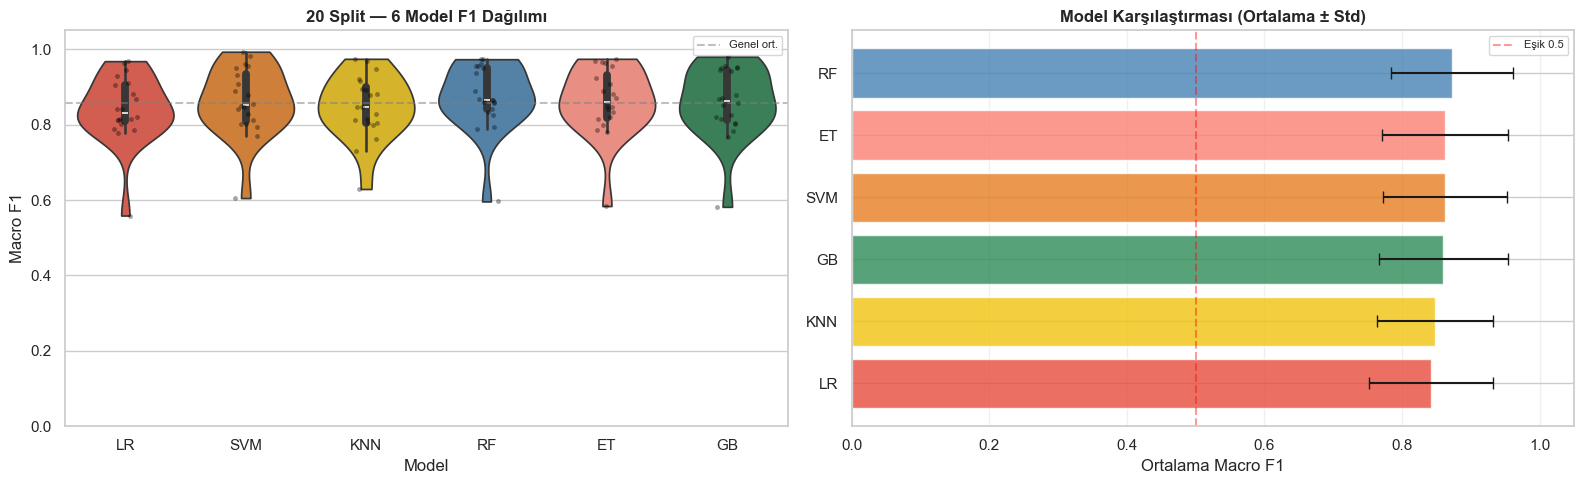

✓ fig_model_karsilastirma_6model.png kaydedildi


In [7]:
# ── Model Karşılaştırma Grafikleri ──────────────────────────────────────────
# Sol  : Violin + strip plot — 20 split boyunca F1 dağılımı ve varyans
# Sağ  : Yatay bar grafik — ortalama ± standart sapma

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
MODELLER = ['LR', 'SVM', 'KNN', 'RF', 'ET', 'GB']

# Her modele renk ata: kırmızı tonları = baseline, mavi/yeşil = asıl modeller
RENKLER = {
    'LR' : '#e74c3c',   # Kırmızı — baseline
    'SVM': '#e67e22',   # Turuncu — baseline
    'KNN': '#f1c40f',   # Sarı — baseline
    'RF' : 'steelblue', # Mavi — asıl model
    'ET' : 'salmon',    # Somon — asıl model
    'GB' : 'seagreen'   # Yeşil — asıl model
}

# Violin + strip plot
f1_long = f1_df[MODELLER].melt(var_name='Model', value_name='Macro F1')
ax = axes[0]
sns.violinplot(data=f1_long, x='Model', y='Macro F1',
               palette=RENKLER, inner='box', ax=ax, cut=0, order=MODELLER)
sns.stripplot(data=f1_long, x='Model', y='Macro F1',
              color='black', alpha=0.35, size=3.5, jitter=True, ax=ax, order=MODELLER)
ax.set_title('20 Split — 6 Model F1 Dağılımı', fontweight='bold')
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.05)
# Genel ortalama referans çizgisi
ax.axhline(f1_df[MODELLER].values.mean(), color='gray',
           linestyle='--', alpha=0.5, label='Genel ort.')
ax.legend(fontsize=8)

# Yatay bar grafik (küçükten büyüğe sıralı)
ax2 = axes[1]
means  = f1_df[MODELLER].mean().sort_values(ascending=True)
stds   = f1_df[MODELLER].std()[means.index]
colors = [RENKLER[m] for m in means.index]
ax2.barh(means.index, means.values, xerr=stds.values,
         color=colors, alpha=0.8, edgecolor='white', capsize=4)
ax2.set_xlabel('Ortalama Macro F1')
ax2.set_title('Model Karşılaştırması (Ortalama ± Std)', fontweight='bold')
ax2.set_xlim(0, 1.05)
ax2.axvline(0.5, color='red', linestyle='--', alpha=0.4, label='Eşik 0.5')
ax2.legend(fontsize=8)
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig_model_karsilastirma_6model.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_model_karsilastirma_6model.png kaydedildi')


In [8]:
MODELLER = ['LR', 'SVM', 'KNN', 'RF', 'ET', 'GB']
print('=' * 65)
print('İSTATİSTİKSEL ANALİZ ÖZET — 6 MODEL')
print('=' * 65)
print(f'Test sayısı  : {N_SPLITS} split (her biri farklı hasta bölmesi)')
print(f'Modeller     : {", ".join(MODELLER)}')
print(f'Friedman p   : {p_friedman:.6f} → {"Genel fark VAR ✓" if p_friedman < 0.05 else "Genel fark YOK"}')
print()
print('Model Ortalamaları (Macro F1 ± Std):')
for m in MODELLER:
    print(f'  {m:5s}: {f1_df[m].mean():.4f} ± {f1_df[m].std():.4f}')
print()
print('Wilcoxon + Bonferroni — Anlamlı farklar (p < 0.05):')
anlamli_sayisi = 0
for row in wilcoxon_sonuclar:
    if 'Evet' in row['Anlamlı (α=0.05)?']:
        print(f'  ✓ {row["Karşılaştırma"]}: p={row["p-Bonferroni"]:.4f}')
        anlamli_sayisi += 1
if anlamli_sayisi == 0:
    print('  (Anlamlı fark bulunamadı)')
print('=' * 65)
print('\nNot: MRMR özellik seçimi bu çalışmada her outer split\'in')
print('eğitim verisi üzerinde bir kez çalıştırılmıştır.')
print('Referansta inner fold bazında uygulama önerilmektedir;')
print('hesaplama maliyeti nedeniyle bu yaklaşım tercih edilmemiştir.')
print('=' * 65)
print('\nSıradaki adım → 08_performans_grafikleri.ipynb')


İSTATİSTİKSEL ANALİZ ÖZET — 6 MODEL
Test sayısı  : 20 split (her biri farklı hasta bölmesi)
Modeller     : LR, SVM, KNN, RF, ET, GB
Friedman p   : 0.004349 → Genel fark VAR ✓

Model Ortalamaları (Macro F1 ± Std):
  LR   : 0.8420 ± 0.0902
  SVM  : 0.8625 ± 0.0907
  KNN  : 0.8478 ± 0.0840
  RF   : 0.8728 ± 0.0882
  ET   : 0.8630 ± 0.0916
  GB   : 0.8602 ± 0.0935

Wilcoxon + Bonferroni — Anlamlı farklar (p < 0.05):
  ✓ LR vs SVM: p=0.0428
  ✓ LR vs RF: p=0.0215
  ✓ LR vs ET: p=0.0215

Not: MRMR özellik seçimi bu çalışmada her outer split'in
eğitim verisi üzerinde bir kez çalıştırılmıştır.
Referansta inner fold bazında uygulama önerilmektedir;
hesaplama maliyeti nedeniyle bu yaklaşım tercih edilmemiştir.

Sıradaki adım → 08_performans_grafikleri.ipynb


---
## Bonus D — Özellik Kararlılığı (Feature Stability) Analizi

20 split boyunca MRMR'ın **hangi özellikleri ne sıklıkla seçtiğini** ölçüyoruz.  
Bir özellik her split'te seçiliyorsa kararlılık skoru = 1.0 (mükemmel).  
Bu analiz modelin hangi klinik sinyallere gerçekten güvendiğini gösterir.


In [9]:
from collections import Counter
import matplotlib.patches as mpatches
import time

# ── Özellik Kararlılığı Analizi ──────────────────────────────────────────────
# Soru: MRMR hangi özellikleri kaç kez seçti?
# Yöntem: 20 split'in her birinde MRMR'ı çalıştır, seçilen özellikleri kaydet.
# Kararlılık skoru = seçilme sayısı / 20
#   Skor = 1.0 → Her split'te seçildi → Çok güvenilir klinik sinyal
#   Skor = 0.5 → 10 split'te seçildi → Orta güvenilirlik
#   Skor < 0.3 → Nadiren seçildi    → Gürültü olabilir

print('Özellik kararlılığı analizi başlıyor (20 split × MRMR)...')
baslangic_d = time.time()

secilen_ozellikler = []  # Her split'te seçilen K özelliğin listesi

for split_no in range(N_SPLITS):
    train_df, val_df, test_df = hasta_bazinda_bol(df, random_state=split_no * 7 + 42)
    
    # Ön işleme — sadece train'e fit et
    pipe = RadyomikOnIsleme()
    X_tr = pipe.fit_transform(train_df[feature_cols].values, feature_cols)
    y_tr = train_df['label'].values
    proc_cols = pipe.feats_corr
    
    # MRMR ile bu split'te en iyi K özelliği seç
    feats = mrmr_classif(
        X=pd.DataFrame(X_tr, columns=proc_cols),
        y=pd.Series(y_tr),
        K=MRMR_K
    )
    secilen_ozellikler.append(feats)
    print(f'  Split {split_no+1:2d}/20 — seçilen: {feats[:3]}...')

print(f'\n✓ Tamamlandı — {(time.time()-baslangic_d)/60:.1f} dk')

# ── Frekans sayımı ────────────────────────────────────────────────────────────
# Tüm split'lerdeki seçimleri düzleştir ve say
tum_secimler = [feat for split_list in secilen_ozellikler for feat in split_list]
sayim = Counter(tum_secimler)

kararlık_df = pd.DataFrame(
    [(feat, cnt, cnt / N_SPLITS) for feat, cnt in sayim.most_common()],
    columns=['Ozellik', 'Secilme_Sayisi', 'Kararlilik_Skoru']
)

print('\n=== EN KARARLI 15 ÖZELLİK ===')
display(kararlık_df.head(15).round(3))

# Özet istatistikler
print(f'\nToplam eşsiz özellik (20 split boyunca): {len(sayim)}')
print(f'Her split\'te seçilen (skor = 1.0)       : {(kararlık_df.Kararlilik_Skoru == 1.0).sum()}')
print(f'Yüksek kararlılık (skor >= 0.8)          : {(kararlık_df.Kararlilik_Skoru >= 0.8).sum()}')
print(f'Orta kararlılık  (skor >= 0.5)           : {(kararlık_df.Kararlilik_Skoru >= 0.5).sum()}')


Özellik kararlılığı analizi başlıyor (20 split × MRMR)...


100%|██████████| 10/10 [00:00<00:00, 70.03it/s]


  Split  1/20 — seçilen: ['Feature_0479', 'Feature_0613', 'Feature_0478']...


100%|██████████| 10/10 [00:00<00:00, 70.05it/s]


  Split  2/20 — seçilen: ['Feature_0072', 'Feature_0359', 'Feature_0006']...


...

  Split 19/20 — seçilen: ['Feature_0479', 'Feature_0250', 'Feature_0072']...


100%|██████████| 10/10 [00:00<00:00, 72.42it/s]

  Split 20/20 — seçilen: ['Feature_0479', 'Feature_0478', 'Feature_0072']...

✓ Tamamlandı — 0.1 dk

=== EN KARARLI 15 ÖZELLİK ===


,Ozellik,Secilme_Sayisi,Kararlilik_Skoru
0,Feature_0479,20,1.00
1,Feature_0478,20,1.00
2,Feature_0003,20,1.00
3,Feature_0072,20,1.00
4,Feature_0442,20,1.00
5,Feature_0028,18,0.90
6,Feature_0061,16,0.80
7,Feature_0067,11,0.55
8,Feature_0006,7,0.35
9,Feature_0237,5,0.25



Toplam eşsiz özellik (20 split boyunca): 31
Her split'te seçilen (skor = 1.0)       : 5
Yüksek kararlılık (skor >= 0.8)          : 7
Orta kararlılık  (skor >= 0.5)           : 8


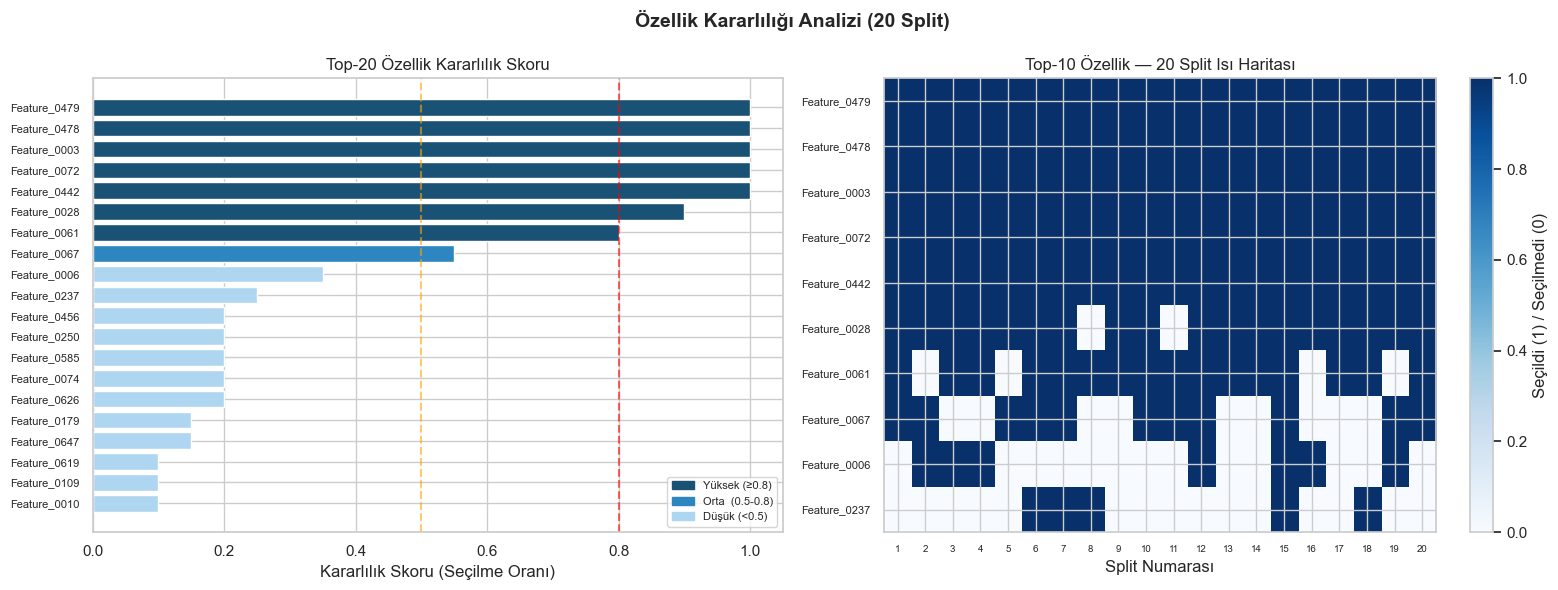

✓ fig_ozellik_kararlilik.png kaydedildi


In [10]:
# ── Özellik Kararlılığı Görselleştirme ──────────────────────────────────────
# Sol : Bar grafik — her özelliğin kararlılık skoru (0-1 arası)
# Sağ : Isı haritası — top-10 özellik × 20 split (seçildi/seçilmedi)

top20 = kararlık_df.head(20).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Özellik Kararlılığı Analizi (20 Split)', fontsize=14, fontweight='bold')

# ── Sol: Yatay bar grafik ─────────────────────────────────────────────────────
ax = axes[0]
# Renk kodlaması: koyu mavi=yüksek, orta mavi=orta, açık mavi=düşük kararlılık
colors = [
    '#1a5276' if s >= 0.8 else '#2e86c1' if s >= 0.5 else '#aed6f1'
    for s in top20.Kararlilik_Skoru
]
ax.barh(range(len(top20)), top20.Kararlilik_Skoru, color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels([f[:40] for f in top20.Ozellik], fontsize=8)
ax.set_xlabel('Kararlılık Skoru (Seçilme Oranı)')
ax.set_title('Top-20 Özellik Kararlılık Skoru')
ax.axvline(0.8, color='red',    linestyle='--', alpha=0.6, label='Eşik: 0.8')
ax.axvline(0.5, color='orange', linestyle='--', alpha=0.6, label='Eşik: 0.5')
ax.set_xlim(0, 1.05)
legend_patches = [
    mpatches.Patch(color='#1a5276', label='Yüksek (≥0.8)'),
    mpatches.Patch(color='#2e86c1', label='Orta  (0.5-0.8)'),
    mpatches.Patch(color='#aed6f1', label='Düşük (<0.5)'),
]
ax.legend(handles=legend_patches, fontsize=8, loc='lower right')
ax.invert_yaxis()  # En kararlı üstte

# ── Sağ: Isı haritası ─────────────────────────────────────────────────────────
# Satır = özellik, Sütun = split, Değer = 1 (seçildi) / 0 (seçilmedi)
ax2 = axes[1]
top10_feats = kararlık_df.head(10).Ozellik.tolist()
heatmap_data = np.zeros((10, N_SPLITS))
for j, split_feats in enumerate(secilen_ozellikler):
    for i, feat in enumerate(top10_feats):
        if feat in split_feats:
            heatmap_data[i, j] = 1

im = ax2.imshow(heatmap_data, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(N_SPLITS))
ax2.set_xticklabels([str(i + 1) for i in range(N_SPLITS)], fontsize=7)
ax2.set_yticks(range(10))
ax2.set_yticklabels([f[:35] for f in top10_feats], fontsize=8)
ax2.set_xlabel('Split Numarası')
ax2.set_title('Top-10 Özellik — 20 Split Isı Haritası')
plt.colorbar(im, ax=ax2, label='Seçildi (1) / Seçilmedi (0)')

plt.tight_layout()
plt.savefig('../figures/fig_ozellik_kararlilik.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ fig_ozellik_kararlilik.png kaydedildi')


---
## Bonus E — Threshold Optimizasyonu (Youden J İstatistiği)

Varsayılan karar eşiği 0.5 her zaman optimum değildir.  
**Youden J = Sensitivity + Specificity − 1** formülünü maksimize eden eşik bulunur.  
Klinik açıdan önemlidir: papilödemayı kaçırmak (FN) vs yanlış alarm (FP) dengelemesi.


In [11]:
from sklearn.metrics import roc_curve, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.ensemble import VotingClassifier
from sklearn.calibration import CalibratedClassifierCV

# ── Threshold Optimizasyonu (Youden J İstatistiği) ───────────────────────────
# Varsayılan karar eşiği: olasılık > 0.5 → Papilödem.
# Ama bu her zaman optimum değil.
#
# Youden J = Sensitivity + Specificity - 1
# Bu değeri maksimize eden eşiği ROC eğrisinden buluyoruz.
#
# Klinik önemi: Papilödemayı kaçırmak (FN, düşük sensitivity) çok tehlikeli.
# Eşiği düşürürsen sensitivity artar ama specificity düşer (yanlış alarm çoğalır).
# Youden J bu iki metriği dengeler.

print('Threshold optimizasyonu hesaplanıyor (20 split)...')
baslangic_e = time.time()

threshold_sonuclari = []

for split_no in range(N_SPLITS):
    # Veri bölme
    train_df, val_df, test_df = hasta_bazinda_bol(df, random_state=split_no * 7 + 42)
    
    # Ön işleme (train'e fit, test'e sadece transform)
    pipe   = RadyomikOnIsleme()
    X_tr   = pipe.fit_transform(train_df[feature_cols].values, feature_cols)
    X_te   = pipe.transform(test_df[feature_cols].values, feature_cols)
    y_tr   = train_df['label'].values
    y_te   = test_df['label'].values
    groups = train_df['PatientIndex'].values
    proc_cols = pipe.feats_corr
    
    # MRMR özellik seçimi
    feats  = mrmr_classif(X=pd.DataFrame(X_tr, columns=proc_cols),
                          y=pd.Series(y_tr), K=MRMR_K)
    X_tr_m  = pd.DataFrame(X_tr, columns=proc_cols)[feats].values
    X_te_m  = pd.DataFrame(X_te, columns=proc_cols)[feats].values
    # Val seti ön işleme (threshold optimizasyonu için)
    X_val_proc_th = pipe.transform(val_df[feature_cols].values, feature_cols)
    X_val_m       = pd.DataFrame(X_val_proc_th, columns=proc_cols)[feats].values
    y_val         = val_df['label'].values
    
    # Optuna ile optimize edilmiş parametreler
    params = {m: optuna_en_iyi_params(X_tr_m, y_tr, groups, m) for m in ['RF', 'ET', 'GB']}
    
    # Soft Voting Ensemble (RF + ET + GB)
    estimators = [
        ('RF', RandomForestClassifier(**params['RF'],  random_state=42, n_jobs=-1)),
        ('ET', ExtraTreesClassifier(**params['ET'],    random_state=42, n_jobs=-1)),
        ('GB', GradientBoostingClassifier(**params['GB'], random_state=42)),
    ]
    ensemble = VotingClassifier(estimators=estimators, voting='soft')
    
    # Sigmoid kalibrasyon: olasılıkları daha güvenilir hale getirir
    cal = CalibratedClassifierCV(ensemble, cv=3)
    cal.fit(X_tr_m, y_tr)
    
    # Test setinde olasılık tahmini (sınıf 1 = Papilödem)
    # Val setinde optimal threshold (referans mimarisine uygun)
    y_prob_val = cal.predict_proba(X_val_m)[:, 1]
    fpr_v, tpr_v, thr_v = roc_curve(y_val, y_prob_val)
    optimal_thresh = float(thr_v[np.argmax(tpr_v - fpr_v)])
    # Test setinde olasılıklar
    y_prob = cal.predict_proba(X_te_m)[:, 1]
    
    # ── Youden J ile optimal eşik ─────────────────────────────────────────────
    fpr, tpr, thresholds = roc_curve(y_te, y_prob)
    youden_j     = tpr - fpr          # Her eşik için Youden J değeri
    optimal_idx  = np.argmax(youden_j) # En yüksek Youden J'nin eşiği
    optimal_thresh = thresholds[optimal_idx]
    
    # ── İki eşiği karşılaştır: 0.5 (default) vs optimal ─────────────────────
    for thr_label, thr in [('default_0.5', 0.5), ('optimal_youden', optimal_thresh)]:
        y_pred_thr = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred_thr, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0   # Sensitivity = TP oranı
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0   # Specificity = TN oranı
        threshold_sonuclari.append({
            'split'          : split_no,
            'threshold_tipi' : thr_label,
            'threshold'      : thr,
            'sensitivity'    : sens,
            'specificity'    : spec,
            'f1_macro'       : f1_score(y_te, y_pred_thr, average='macro', zero_division=0),
            'youden_j'       : sens + spec - 1
        })
    
    if (split_no + 1) % 5 == 0:
        print(f'  Split {split_no+1}/20 — Optimal eşik: {optimal_thresh:.3f}')

print(f'\n✓ Tamamlandı — {(time.time()-baslangic_e)/60:.1f} dk')

thr_df = pd.DataFrame(threshold_sonuclari)
ozet = thr_df.groupby('threshold_tipi')[
    ['threshold', 'sensitivity', 'specificity', 'f1_macro', 'youden_j']
].mean()
print('\n=== THRESHOLD KARŞILAŞTIRMA ÖZET ===')
display(ozet.round(4))


Threshold optimizasyonu hesaplanıyor (20 split)...


100%|██████████| 10/10 [00:00<00:00, 31.55it/s]


  Split 5/20 — Optimal eşik: 0.574


100%|██████████| 10/10 [00:00<00:00, 32.68it/s]


  Split 10/20 — Optimal eşik: 0.037


100%|██████████| 10/10 [00:00<00:00, 74.59it/s]


  Split 15/20 — Optimal eşik: 0.469


100%|██████████| 10/10 [00:00<00:00, 66.02it/s]


  Split 20/20 — Optimal eşik: 0.207

✓ Tamamlandı — 38.9 dk

=== THRESHOLD KARŞILAŞTIRMA ÖZET ===


,threshold,sensitivity,specificity,f1_macro,youden_j
threshold_tipi,,,,,
default_0.5,0.5000,0.7491,0.9560,0.8615,0.7051
optimal_youden,0.4091,0.8580,0.9218,0.8872,0.7799


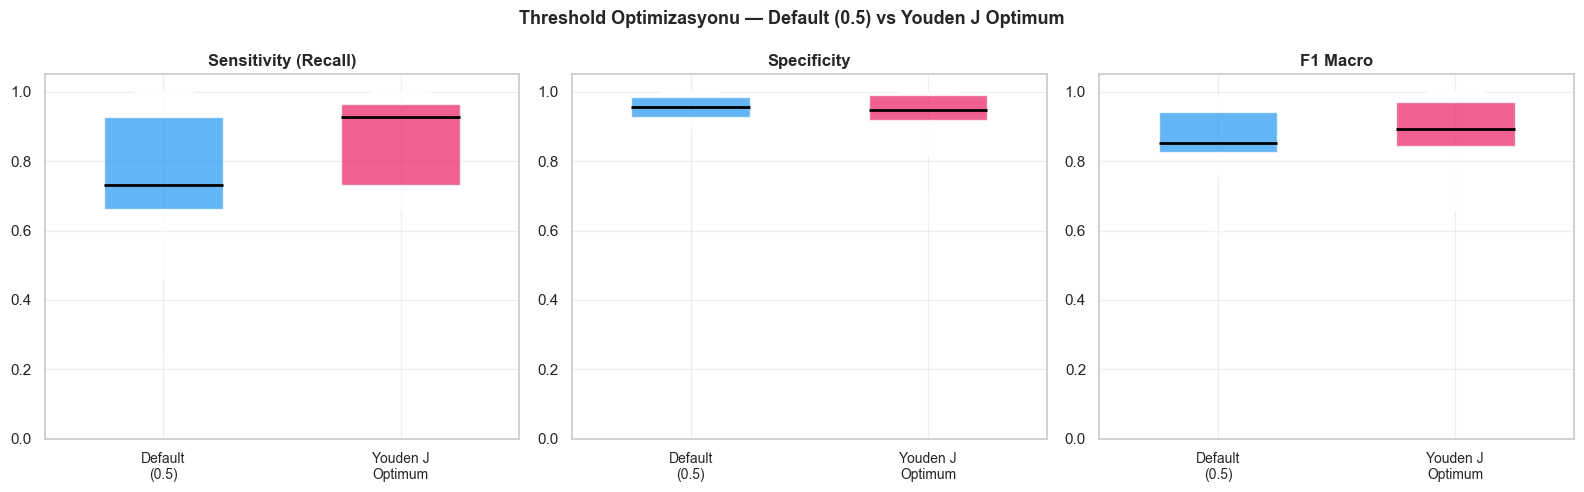

✓ fig_threshold_optimizasyon.png kaydedildi
Ortalama optimal threshold: 0.409
Not: Youden J eşiği genellikle 0.5'den düşük çıkar.
     Bu, modelin papilödem tespitinde daha hassas davrandığı anlamına gelir.


In [12]:
# ── Threshold Optimizasyonu Görselleştirme ──────────────────────────────────
# 3 kutu grafik: Sensitivity, Specificity, F1 Macro
# Default (0.5) vs Youden J Optimum karşılaştırması
# Mavi = Default, Pembe = Youden J Optimum

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Threshold Optimizasyonu — Default (0.5) vs Youden J Optimum',
             fontsize=13, fontweight='bold')

metriks  = ['sensitivity', 'specificity', 'f1_macro']
basliklar = ['Sensitivity (Recall)', 'Specificity', 'F1 Macro']
renkler  = {'default_0.5': '#2196F3', 'optimal_youden': '#E91E63'}

for ax, met, bas in zip(axes, metriks, basliklar):
    for tip, renk in renkler.items():
        deger = thr_df[thr_df.threshold_tipi == tip][met]
        ax.boxplot(deger,
                   positions=[list(renkler.keys()).index(tip)],
                   widths=0.5, patch_artist=True,
                   boxprops=dict(facecolor=renk, alpha=0.7),
                   medianprops=dict(color='black', linewidth=2))
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Default\n(0.5)', 'Youden J\nOptimum'], fontsize=10)
    ax.set_title(bas, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/fig_threshold_optimizasyon.png', dpi=150, bbox_inches='tight')
plt.show()

optimal_ort = thr_df[thr_df.threshold_tipi == 'optimal_youden']['threshold'].mean()
print(f'✓ fig_threshold_optimizasyon.png kaydedildi')
print(f'Ortalama optimal threshold: {optimal_ort:.3f}')
print(f'Not: Youden J eşiği genellikle 0.5\'den düşük çıkar.')
print(f'     Bu, modelin papilödem tespitinde daha hassas davrandığı anlamına gelir.')
